In [2]:
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf

from tensorflow.keras.datasets import fashion_mnist
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D
from tensorflow.keras.layers import Dense, Flatten, Dropout
from tensorflow.keras.utils import to_categorical

from sklearn.metrics import classification_report
from sklearn.metrics import confusion_matrix
import seaborn as sns

In [3]:
(x_train, y_train), (x_test, y_test) = fashion_mnist.load_data()

In [4]:
print("Training Shape:", x_train.shape)
print("Testing Shape:", x_test.shape)

Training Shape: (60000, 28, 28)
Testing Shape: (10000, 28, 28)


In [6]:
class_names = [
    'T-shirt/top',
    'Trouser',
    'Pullover',
    'Dress',
    'Coat',
    'Sandal',
    'Shirt',
    'Sneaker',
    'Bag',
    'Ankle boot'
]

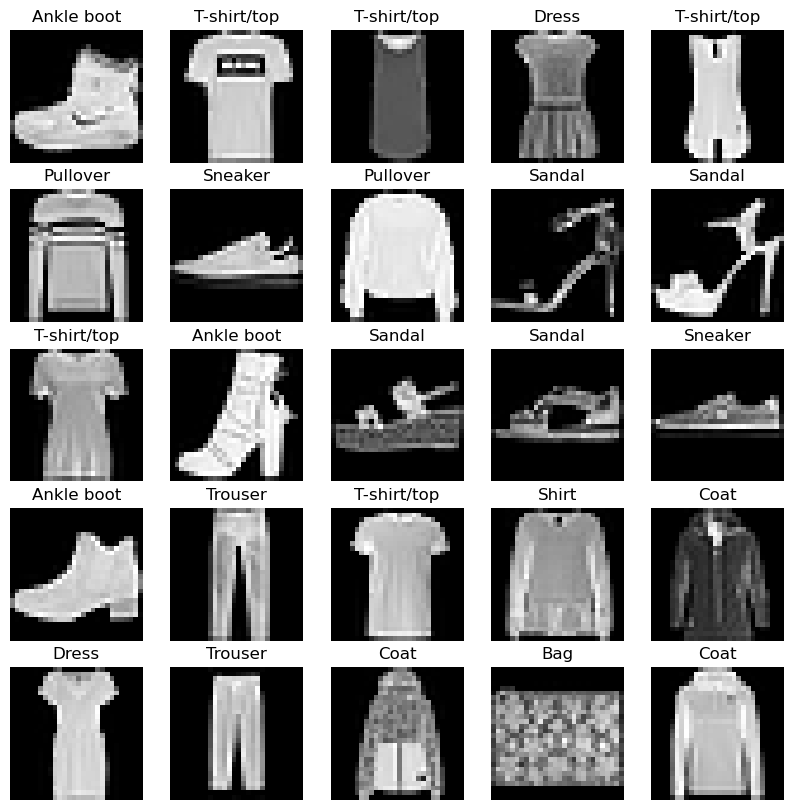

In [7]:
plt.figure(figsize=(10,10))

for i in range(25):
    plt.subplot(5,5,i+1)
    plt.imshow(x_train[i], cmap='gray')
    plt.title(class_names[y_train[i]])
    plt.axis('off')

plt.show()

In [8]:
x_train = x_train.reshape(60000, 28, 28, 1)
x_test = x_test.reshape(10000, 28, 28, 1)

print(x_train.shape)
print(x_test.shape)

(60000, 28, 28, 1)
(10000, 28, 28, 1)


In [9]:
x_train = x_train.astype('float32') / 255
x_test = x_test.astype('float32') / 255

In [10]:
y_train_cat = to_categorical(y_train, 10)
y_test_cat = to_categorical(y_test, 10)

In [13]:
print(y_train[6])
print(y_train_cat[6])

7
[0. 0. 0. 0. 0. 0. 0. 1. 0. 0.]


In [14]:
model = Sequential()

In [15]:
# First Convolution Layer
model.add(Conv2D(
    32,
    kernel_size=(3,3),
    activation='relu',
    input_shape=(28,28,1)
))

# Pooling Layer
model.add(MaxPooling2D(pool_size=(2,2)))

# Second Convolution Layer
model.add(Conv2D(
    64,
    kernel_size=(3,3),
    activation='relu'
))

# Second Pooling Layer
model.add(MaxPooling2D(pool_size=(2,2)))

# Flatten Layer
model.add(Flatten())

# Dense Layer
model.add(Dense(128, activation='relu'))

# Dropout Layer
model.add(Dropout(0.5))

# Output Layer
model.add(Dense(10, activation='softmax'))

C:\Users\AlokVerma\anaconda3\Lib\site-packages\keras\src\layers\convolutional\base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [16]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                      │ (None, 26, 26, 32)          │             320 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d (MaxPooling2D)         │ (None, 13, 13, 32)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_1 (Conv2D)                    │ (None, 11, 11, 64)          │          18,496 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_1 (MaxPooling2D)       │ (None, 5, 5, 64)            │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ flatten (Flatten)                    │ (None, 1600)                │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense (Dense)                        │ (None, 128)                 │         204,928 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout (Dropout)                    │ (None, 128)                 │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_1 (Dense)                      │ (None, 10)                  │           1,290 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 225,034 (879.04 KB)

 Trainable params: 225,034 (879.04 KB)

 Non-trainable params: 0 (0.00 B)

In [18]:
model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

In [19]:
history = model.fit(
    x_train,
    y_train_cat,
    batch_size=64,
    epochs=15,
    validation_data=(x_test, y_test_cat)
)

Epoch 1/15
938/938 ━━━━━━━━━━━━━━━━━━━━ 107s 99ms/step - accuracy: 0.7887 - loss: 0.5873 - val_accuracy: 0.8517 - val_loss: 0.3976
Epoch 2/15
938/938 ━━━━━━━━━━━━━━━━━━━━ 90s 95ms/step - accuracy: 0.8594 - loss: 0.3920 - val_accuracy: 0.8775 - val_loss: 0.3313
Epoch 3/15
938/938 ━━━━━━━━━━━━━━━━━━━━ 185s 142ms/step - accuracy: 0.8770 - loss: 0.3417 - val_accuracy: 0.8907 - val_loss: 0.3033
Epoch 4/15
938/938 ━━━━━━━━━━━━━━━━━━━━ 120s 118ms/step - accuracy: 0.8870 - loss: 0.3137 - val_accuracy: 0.8936 - val_loss: 0.2878
Epoch 5/15
938/938 ━━━━━━━━━━━━━━━━━━━━ 104s 111ms/step - accuracy: 0.8964 - loss: 0.2859 - val_accuracy: 0.9008 - val_loss: 0.2713
Epoch 6/15
938/938 ━━━━━━━━━━━━━━━━━━━━ 107s 114ms/step - accuracy: 0.9028 - loss: 0.2667 - val_accuracy: 0.9045 - val_loss: 0.2607
Epoch 7/15
938/938 ━━━━━━━━━━━━━━━━━━━━ 142s 114ms/step - accuracy: 0.9095 - loss: 0.2510 - val_accuracy: 0.9067 - val_loss: 0.2543
Epoch 8/15
938/938 ━━━━━━━━━━━━━━━━━━━━ 115s 123ms/step - accuracy: 0.9130 - lo

In [20]:
test_loss, test_acc = model.evaluate(x_test, y_test_cat)

print("Test Accuracy:", test_acc)
print("Test Loss:", test_loss)

313/313 ━━━━━━━━━━━━━━━━━━━━ 6s 20ms/step - accuracy: 0.9141 - loss: 0.2485
Test Accuracy: 0.9140999913215637
Test Loss: 0.24849805235862732


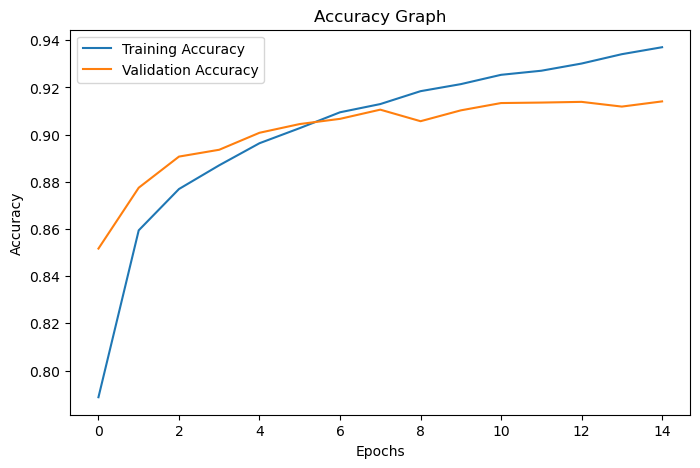

In [21]:
plt.figure(figsize=(8,5))

plt.plot(history.history['accuracy'], label='Training Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')

plt.title('Accuracy Graph')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')

plt.legend()
plt.show()

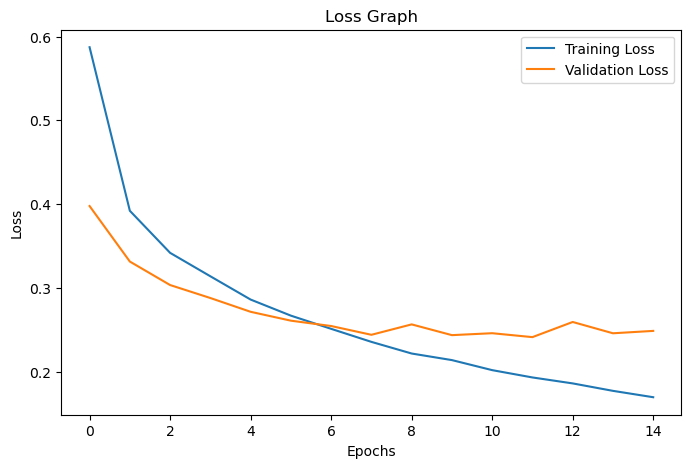

In [22]:
plt.figure(figsize=(8,5))

plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')

plt.title('Loss Graph')
plt.xlabel('Epochs')
plt.ylabel('Loss')

plt.legend()
plt.show()

In [23]:
predictions = model.predict(x_test)

predicted_classes = np.argmax(predictions, axis=1)

313/313 ━━━━━━━━━━━━━━━━━━━━ 5s 14ms/step


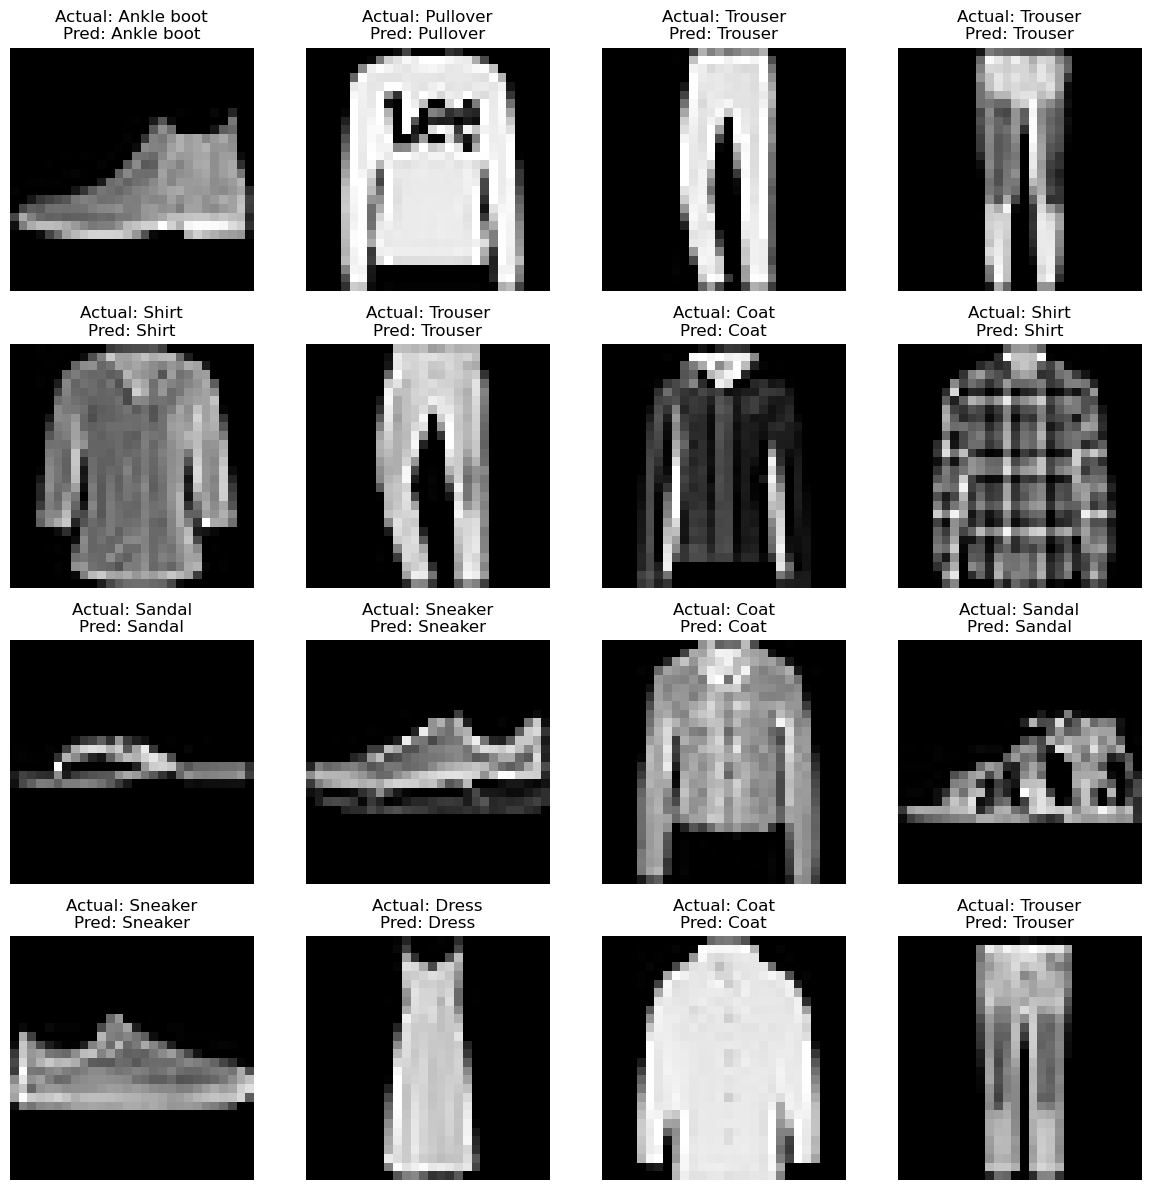

In [24]:
plt.figure(figsize=(12,12))

for i in range(16):

    plt.subplot(4,4,i+1)

    plt.imshow(x_test[i].reshape(28,28), cmap='gray')

    plt.title(
        f"Actual: {class_names[y_test[i]]}\nPred: {class_names[predicted_classes[i]]}"
    )

    plt.axis('off')

plt.tight_layout()
plt.show()

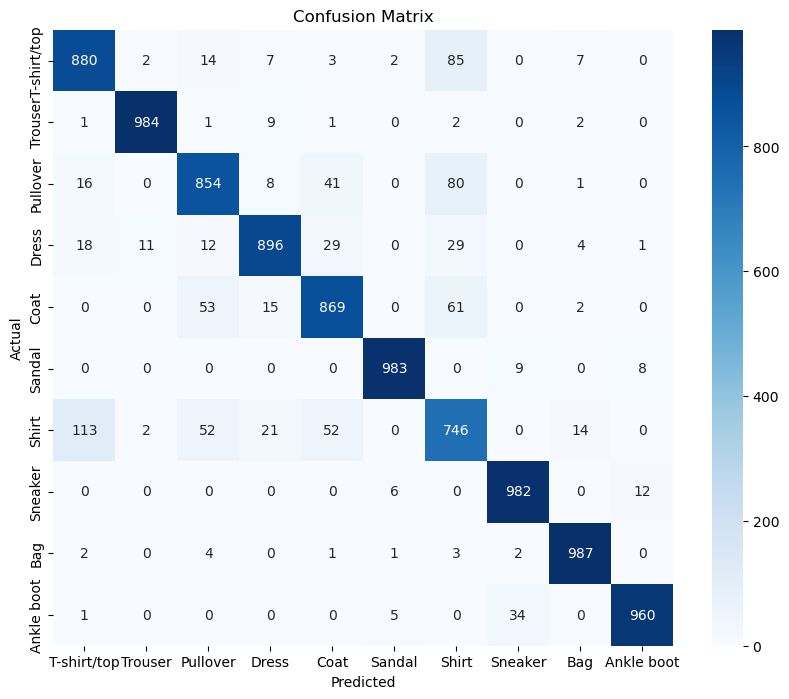

In [25]:
cm = confusion_matrix(y_test, predicted_classes)

plt.figure(figsize=(10,8))

sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=class_names,
    yticklabels=class_names
)

plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix')

plt.show()

In [26]:
print(classification_report(
    y_test,
    predicted_classes,
    target_names=class_names
))

              precision    recall  f1-score   support

 T-shirt/top       0.85      0.88      0.87      1000
     Trouser       0.98      0.98      0.98      1000
    Pullover       0.86      0.85      0.86      1000
       Dress       0.94      0.90      0.92      1000
        Coat       0.87      0.87      0.87      1000
      Sandal       0.99      0.98      0.98      1000
       Shirt       0.74      0.75      0.74      1000
     Sneaker       0.96      0.98      0.97      1000
         Bag       0.97      0.99      0.98      1000
  Ankle boot       0.98      0.96      0.97      1000

    accuracy                           0.91     10000
   macro avg       0.91      0.91      0.91     10000
weighted avg       0.91      0.91      0.91     10000



In [27]:
model.save("fashion_mnist_cnn_model.h5")